# Brain Tumor Classification Using Transfer Learning
### VGG16 | ResNet50 | Xception | EfficientNetB2

---

**Course:** Deep Learning and Reinforcement Learning — ISOM 678

---

**Submitted by:**

| Name |
|------|
| Jean De Dieu Niyonteze|
| Mandingwa Timothy |


---

**Date:** April 24, 2026

---

#### Imports and Setup 

In [2]:
import os
import re
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

print(f"TensorFlow Version: {tf.__version__}")
print(f"GPUs Available: {len(tf.config.list_physical_devices('GPU'))}")

TensorFlow Version: 2.20.0
GPUs Available: 0


#### Preprocessing

In [3]:
# Dataset paths
ARCHIVE_DIR = os.path.join(os.getcwd(), 'archive')
TRAIN_DIR   = os.path.join(ARCHIVE_DIR, 'Training')
TEST_DIR    = os.path.join(ARCHIVE_DIR, 'Testing')

# Outputs folder for models, plots, and reports
OUTPUT_DIR = os.path.join(os.getcwd(), 'outputs')
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"TRAIN_DIR : {TRAIN_DIR}")
print(f"TEST_DIR  : {TEST_DIR}")
print(f"OUTPUT_DIR: {OUTPUT_DIR}")

if not os.path.isdir(TRAIN_DIR) or not os.path.isdir(TEST_DIR):
    raise ValueError("Could not find 'Training' or 'Testing' inside the 'archive' folder. "
                     "Make sure archive/ is in the same directory as this notebook.")

BATCH_SIZE = 32
IMAGE_SIZE = (224, 224)
AUTOTUNE   = tf.data.AUTOTUNE

TRAIN_DIR : c:\Users\HP\Desktop\DL_Project\archive\Training
TEST_DIR  : c:\Users\HP\Desktop\DL_Project\archive\Testing
OUTPUT_DIR: c:\Users\HP\Desktop\DL_Project\outputs


In [4]:
# Reload datasets with validation split from Training folder
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Class names:", class_names)
print("Number of classes:", num_classes)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)


Found 5600 files belonging to 4 classes.
Using 4480 files for training.
Found 5600 files belonging to 4 classes.
Using 1120 files for validation.
Found 1600 files belonging to 4 classes.
Class names: ['glioma', 'meningioma', 'notumor', 'pituitary']
Number of classes: 4


In [5]:
# Compute class weights to handle class imbalance
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

all_labels = []
for _, labels in train_ds.unbatch():
    all_labels.append(int(labels.numpy()))

all_labels = np.array(all_labels)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(all_labels),
    y=all_labels
)

class_weight_dict = dict(enumerate(class_weights))
print("Class weight dict:", class_weight_dict)


Class weight dict: {0: np.float64(0.9824561403508771), 1: np.float64(0.9955555555555555), 2: np.float64(1.018181818181818), 3: np.float64(1.0044843049327354)}


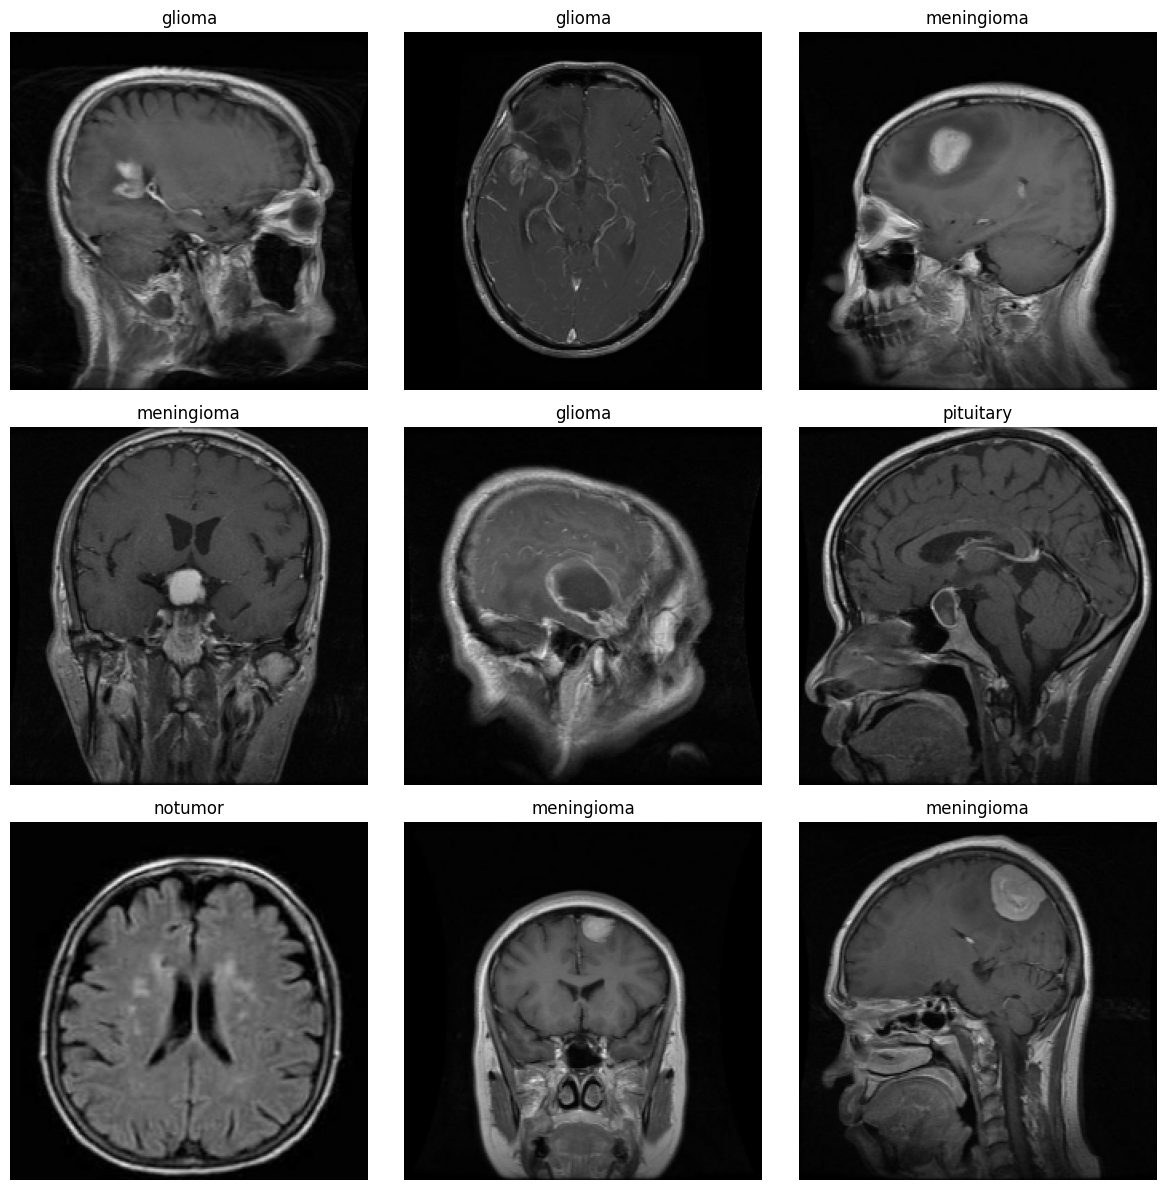

In [6]:
# Visualize some sample images from the training dataset
plt.figure(figsize=(12, 12))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.tight_layout()
plt.show()


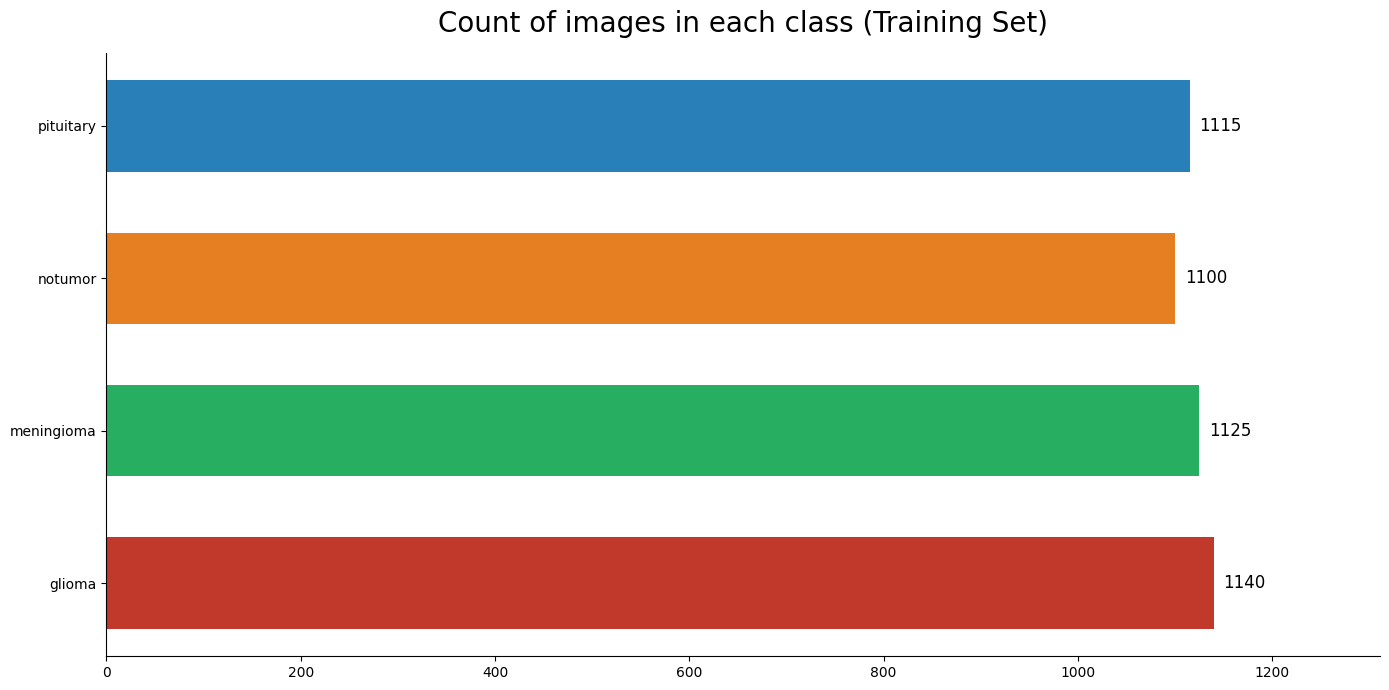

In [7]:
# Count of images in each class in train data
class_counts = {name: 0 for name in class_names}
for _, labels in train_ds.unbatch():
    label = int(labels.numpy())
    class_counts[class_names[label]] += 1

colors = ['#c0392b', '#27ae60', '#e67e22', '#2980b9']  # red, green, orange, blue

fig, ax = plt.subplots(figsize=(14, 7))

bars = ax.barh(list(class_counts.keys()), list(class_counts.values()), color=colors, height=0.6)

# Add count labels at end of each bar
for bar, value in zip(bars, class_counts.values()):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height() / 2,
            str(value), va='center', ha='left', fontsize=12)

ax.set_title('Count of images in each class (Training Set)', fontsize=20, pad=15)
ax.set_xlabel('')
ax.set_ylabel('')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(0, max(class_counts.values()) * 1.15)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "class_distribution.png"), dpi=300, bbox_inches="tight")
plt.show()

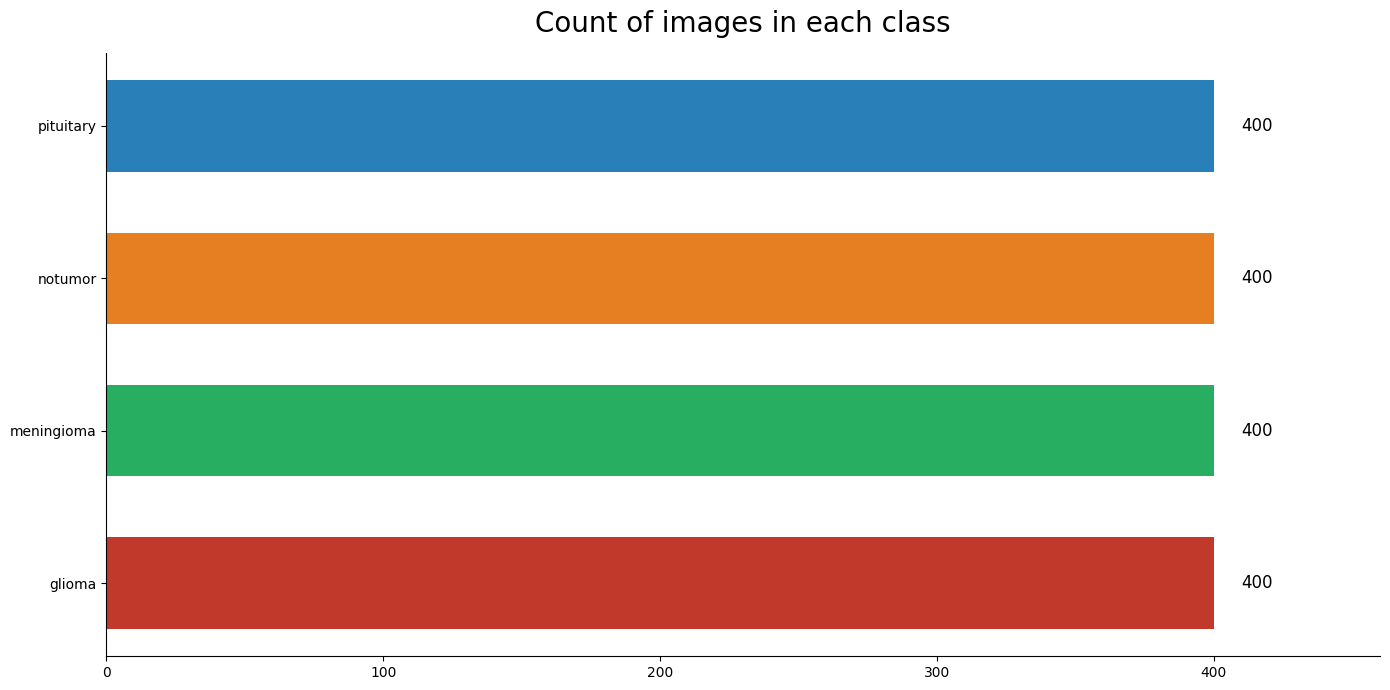

In [33]:
# Count of images in each class in test data
class_counts = {name: 0 for name in class_names}
for _, labels in test_ds.unbatch():
    label = int(labels.numpy())
    class_counts[class_names[label]] += 1

colors = ['#c0392b', '#27ae60', '#e67e22', '#2980b9']  # red, green, orange, blue

fig, ax = plt.subplots(figsize=(14, 7))

bars = ax.barh(list(class_counts.keys()), list(class_counts.values()), color=colors, height=0.6)

# Add count labels at end of each bar
for bar, value in zip(bars, class_counts.values()):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height() / 2,
            str(value), va='center', ha='left', fontsize=12)

ax.set_title('Count of images in each class', fontsize=20, pad=15)
ax.set_xlabel('')
ax.set_ylabel('')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(0, max(class_counts.values()) * 1.15)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "class_distribution.png"), dpi=300, bbox_inches="tight")
plt.show()

In [34]:
# Data augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

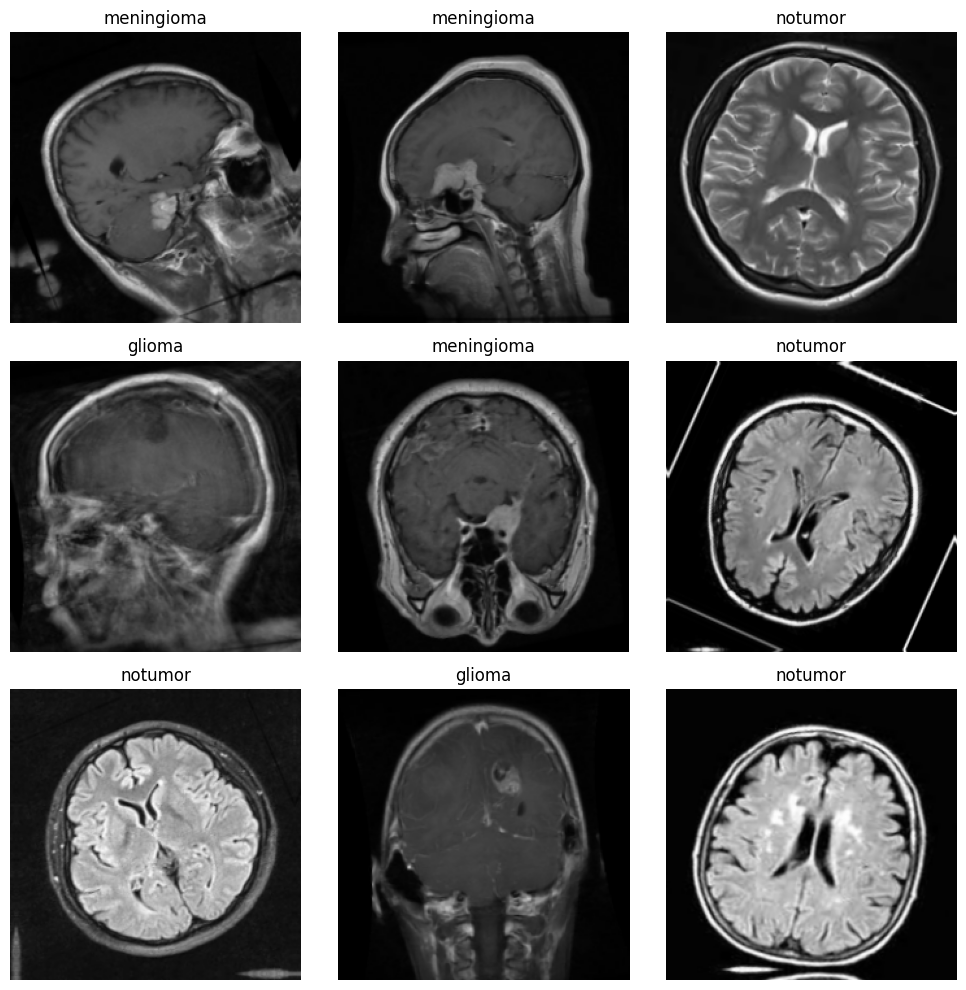

In [35]:
# Visualize augmented images
# Note: Augmentation is random, so each run will show different transformations
# We will visualize the augmented images from the first batch of the training dataset.

plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    augmented_images = data_augmentation(images)
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.tight_layout()
plt.show()


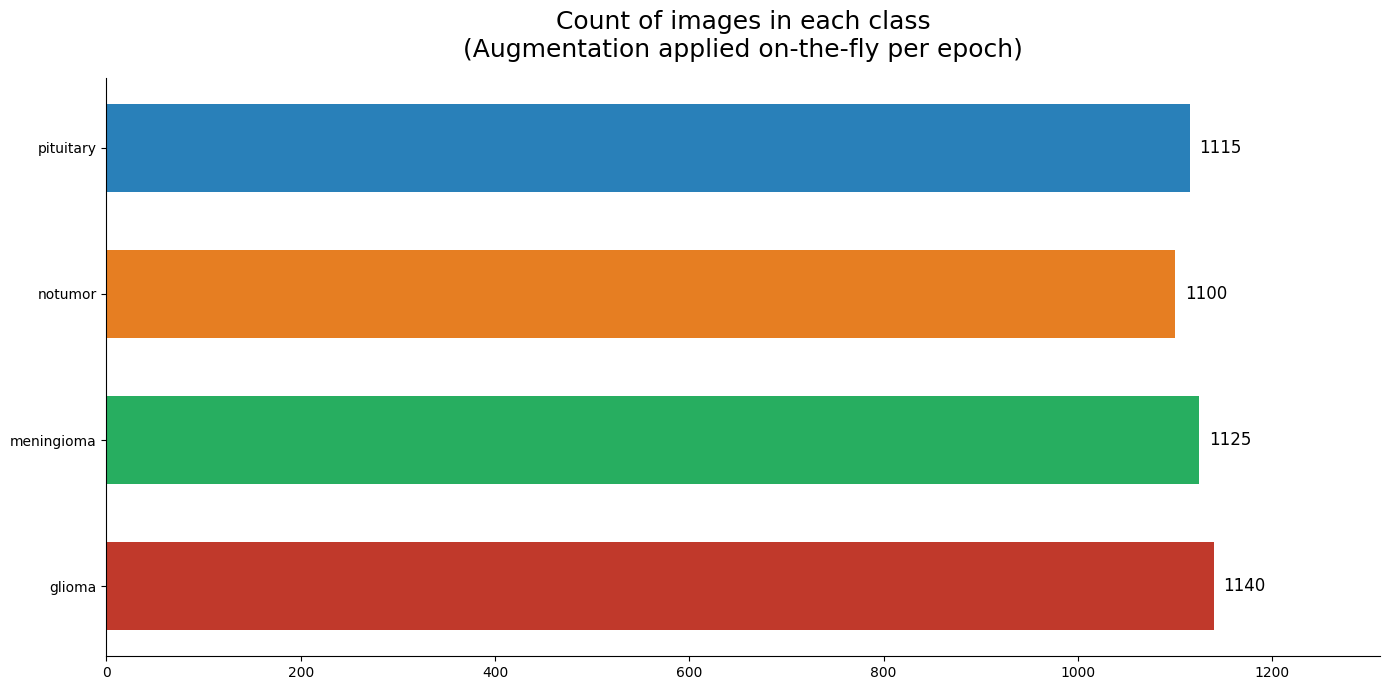

In [36]:
# Count of images in each class (after data augmentation applied)
class_counts = {name: 0 for name in class_names}
for _, labels in train_ds.unbatch():
    label = int(labels.numpy())
    class_counts[class_names[label]] += 1

colors = ['#c0392b', '#27ae60', '#e67e22', '#2980b9']

fig, ax = plt.subplots(figsize=(14, 7))

bars = ax.barh(list(class_counts.keys()), list(class_counts.values()), color=colors, height=0.6)

for bar, value in zip(bars, class_counts.values()):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height() / 2,
            str(value), va='center', ha='left', fontsize=12)

ax.set_title('Count of images in each class\n(Augmentation applied on-the-fly per epoch)', fontsize=18, pad=15)
ax.set_xlabel('')
ax.set_ylabel('')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(0, max(class_counts.values()) * 1.15)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "class_distribution_augmented.png"), dpi=300, bbox_inches="tight")
plt.show()

#### Building Deep Learning Model - VGG16

In [37]:
# Load VGG16 base model
vgg_base = tf.keras.applications.VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)
vgg_base.trainable = False

model_vgg = models.Sequential([
    tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
], name="augmentation_vgg"),
    layers.Lambda(tf.keras.applications.vgg16.preprocess_input),
    vgg_base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation="softmax")
])
model_vgg.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ augmentation_vgg (Sequential)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_4 (Lambda)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

In [38]:
model_vgg.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


In [39]:
def get_callbacks():
    return [
        EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.2,
            patience=3,
            verbose=1
        )
    ]

#### Training, Testing & Evaluation - VGG16

In [ ]:
vgg_start = time.time()

history_vgg = model_vgg.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=get_callbacks(),
    class_weight=class_weight_dict
)

# --- Fine-tuning: unfreeze last 7 layers of VGG16 (full block5) ---
vgg_base.trainable = True
for layer in vgg_base.layers[:-7]:
    layer.trainable = False

model_vgg.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_vgg_ft = model_vgg.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=get_callbacks(),
    class_weight=class_weight_dict
)

# Merge initial + fine-tuning histories for plotting
for k in history_vgg.history:
    history_vgg.history[k].extend(history_vgg_ft.history[k])

# Save the model after training
model_vgg.save(os.path.join(OUTPUT_DIR, "vgg16_model.keras"))
print("VGG16 model saved.")

vgg_time = time.time() - vgg_start
print(f"VGG16 Total Training Time: {vgg_time:.2f} seconds ({vgg_time/60:.2f} minutes)")

Epoch 1/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 753s 5s/step - accuracy: 0.3750 - loss: 2.7578 - val_accuracy: 0.5804 - val_loss: 1.0879 - learning_rate: 1.0000e-04
Epoch 2/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 701s 5s/step - accuracy: 0.5520 - loss: 1.2818 - val_accuracy: 0.6955 - val_loss: 0.7741 - learning_rate: 1.0000e-04
Epoch 3/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 699s 5s/step - accuracy: 0.6344 - loss: 0.9436 - val_accuracy: 0.7527 - val_loss: 0.6426 - learning_rate: 1.0000e-04
Epoch 4/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 720s 5s/step - accuracy: 0.6848 - loss: 0.8063 - val_accuracy: 0.7795 - val_loss: 0.5705 - learning_rate: 1.0000e-04
Epoch 5/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 704s 5s/step - accuracy: 0.7020 - loss: 0.7491 - val_accuracy: 0.8027 - val_loss: 0.5329 - learning_rate: 1.0000e-04
Epoch 6/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 702s 5s/step - accuracy: 0.7364 - loss: 0.6738 - val_accuracy: 0.8259 - val_loss: 0.4951 - learning_rate: 1.0000e-04
Epoch 7/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 698s 5s/step - acc

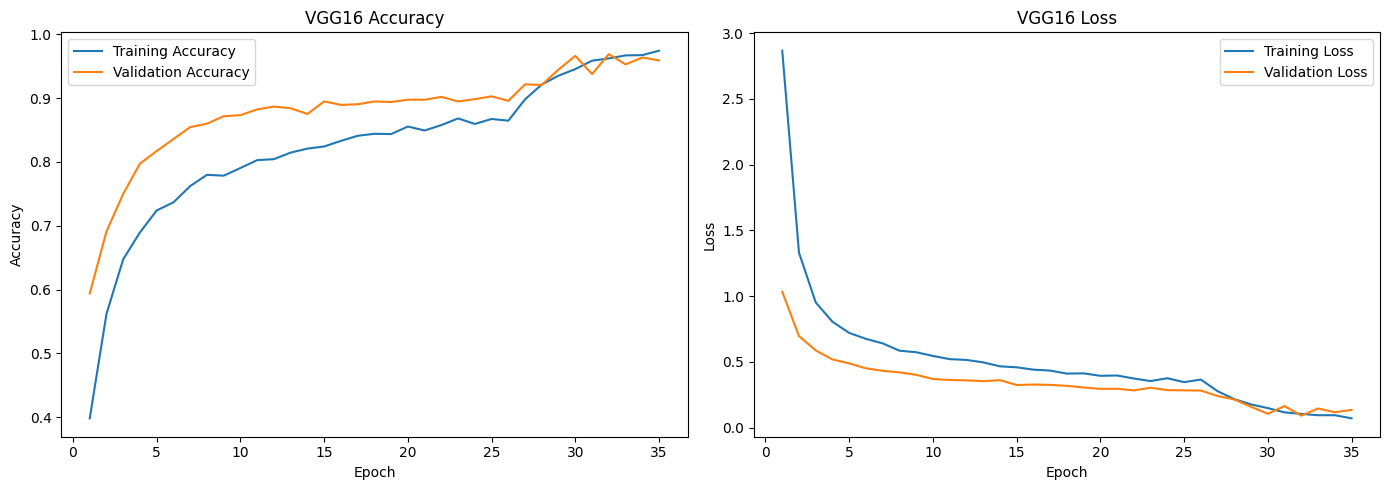

In [17]:
# Single training history
acc = history_vgg.history['accuracy']
val_acc = history_vgg.history['val_accuracy']

loss = history_vgg.history['loss']
val_loss = history_vgg.history['val_loss']

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('VGG16 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('VGG16 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "vgg16_training_curves.png"), dpi=300, bbox_inches="tight")
plt.show()

In [18]:
test_loss_vgg, test_acc_vgg = model_vgg.evaluate(test_ds)
print("VGG16 Test Accuracy:", test_acc_vgg)
print("VGG16 Test Loss:", test_loss_vgg)


50/50 ━━━━━━━━━━━━━━━━━━━━ 181s 4s/step - accuracy: 0.9325 - loss: 0.4944
VGG16 Test Accuracy: 0.9325000047683716
VGG16 Test Loss: 0.4944133460521698


In [19]:
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model_vgg.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Classification Report for VGG16:\n")
print(classification_report(y_true, y_pred, target_names=class_names))


Classification Report for VGG16:

              precision    recall  f1-score   support

      glioma       0.98      0.80      0.88       400
  meningioma       0.87      0.94      0.91       400
     notumor       0.93      1.00      0.96       400
   pituitary       0.96      0.99      0.98       400

    accuracy                           0.93      1600
   macro avg       0.94      0.93      0.93      1600
weighted avg       0.94      0.93      0.93      1600



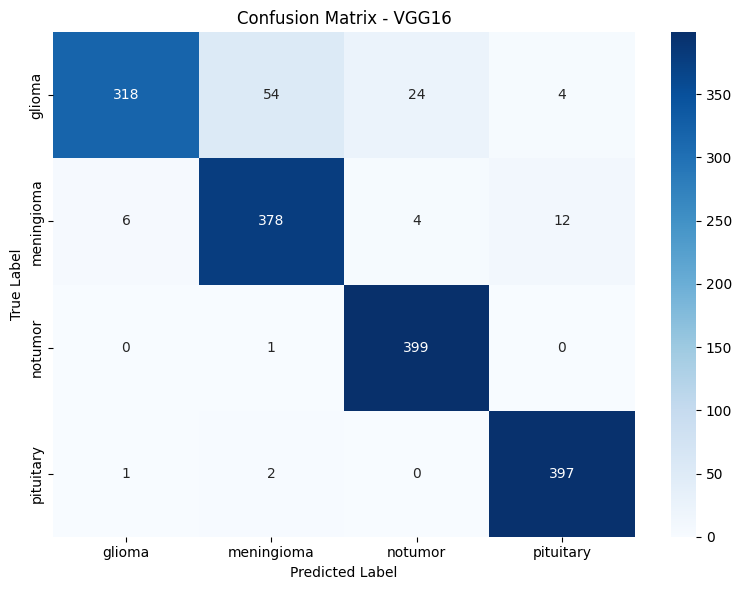

In [20]:
cm_vgg = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_vgg, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - VGG16")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "vgg16_confusion_matrix.png"), dpi=300, bbox_inches="tight")
plt.show()

In [21]:
report_vgg = classification_report(y_true, y_pred, target_names=class_names)

with open(os.path.join(OUTPUT_DIR, "vgg16_classification_report.txt"), "w") as f:
    f.write(report_vgg)

print(report_vgg)


              precision    recall  f1-score   support

      glioma       0.98      0.80      0.88       400
  meningioma       0.87      0.94      0.91       400
     notumor       0.93      1.00      0.96       400
   pituitary       0.96      0.99      0.98       400

    accuracy                           0.93      1600
   macro avg       0.94      0.93      0.93      1600
weighted avg       0.94      0.93      0.93      1600



In [22]:
print(os.listdir(OUTPUT_DIR))


['class_distribution.png', 'class_distribution_augmented.png', 'vgg16_classification_report.txt', 'vgg16_confusion_matrix.png', 'vgg16_model.keras', 'vgg16_training_curves.png']


#### Training, Testing & Evaluation - ResNet50

In [23]:
# Load ResNet50 base model
resnet_base = tf.keras.applications.ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)
resnet_base.trainable = False

model_resnet = models.Sequential([
    tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
], name="augmentation_resnet"),
    layers.Lambda(tf.keras.applications.resnet50.preprocess_input),
    resnet_base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation="softmax")
])
model_resnet.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ augmentation_resnet             │ ?                      │   0 (unbuilt) │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_1 (Lambda)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 23,587,712 (89.98 MB)

In [24]:
resnet_start = time.time()

# Compile the model
model_resnet.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_resnet = model_resnet.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=get_callbacks(),
    class_weight=class_weight_dict
)

# --- Fine-tuning: unfreeze last 15 layers of ResNet50 ---
resnet_base.trainable = True
for layer in resnet_base.layers[:-15]:
    layer.trainable = False

model_resnet.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_resnet_ft = model_resnet.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=get_callbacks(),
    class_weight=class_weight_dict
)

# Merge histories
for k in history_resnet.history:
    history_resnet.history[k].extend(history_resnet_ft.history[k])

# Save the model after training
model_resnet.save(os.path.join(OUTPUT_DIR, "resnet50_model.keras"))
print("ResNet50 model saved.")

resnet_time = time.time() - resnet_start
print(f"ResNet50 Total Training Time: {resnet_time:.2f} seconds ({resnet_time/60:.2f} minutes)")

Epoch 1/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 290s 2s/step - accuracy: 0.5643 - loss: 1.0762 - val_accuracy: 0.8179 - val_loss: 0.5426 - learning_rate: 1.0000e-04
Epoch 2/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 283s 2s/step - accuracy: 0.7752 - loss: 0.5931 - val_accuracy: 0.8634 - val_loss: 0.4018 - learning_rate: 1.0000e-04
Epoch 3/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 282s 2s/step - accuracy: 0.8210 - loss: 0.4882 - val_accuracy: 0.8723 - val_loss: 0.3628 - learning_rate: 1.0000e-04
Epoch 4/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 281s 2s/step - accuracy: 0.8308 - loss: 0.4458 - val_accuracy: 0.8777 - val_loss: 0.3239 - learning_rate: 1.0000e-04
Epoch 5/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 285s 2s/step - accuracy: 0.8482 - loss: 0.3953 - val_accuracy: 0.8866 - val_loss: 0.3099 - learning_rate: 1.0000e-04
Epoch 6/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 283s 2s/step - accuracy: 0.8569 - loss: 0.3788 - val_accuracy: 0.8911 - val_loss: 0.2947 - learning_rate: 1.0000e-04
Epoch 7/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 286s 2s/step - acc

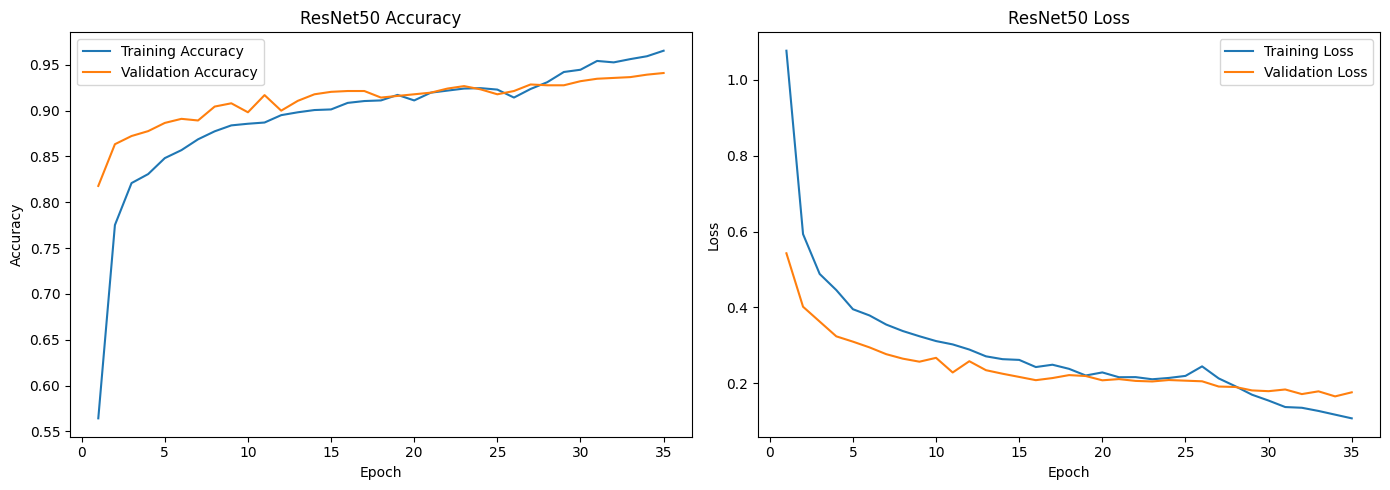

In [25]:
# Single training history
acc_res = history_resnet.history['accuracy']
val_acc_res = history_resnet.history['val_accuracy']

loss_res = history_resnet.history['loss']
val_loss_res = history_resnet.history['val_loss']

epochs_range_res = range(1, len(acc_res) + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range_res, acc_res, label='Training Accuracy')
plt.plot(epochs_range_res, val_acc_res, label='Validation Accuracy')
plt.title('ResNet50 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range_res, loss_res, label='Training Loss')
plt.plot(epochs_range_res, val_loss_res, label='Validation Loss')
plt.title('ResNet50 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "resnet50_accuracy_loss.png"), dpi=300, bbox_inches="tight")
plt.show()

In [26]:
test_loss_resnet, test_acc_resnet = model_resnet.evaluate(test_ds)
print("ResNet50 Test Accuracy:", test_acc_resnet)
print("ResNet50 Test Loss:", test_loss_resnet)

50/50 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - accuracy: 0.8994 - loss: 0.4269
ResNet50 Test Accuracy: 0.8993750214576721
ResNet50 Test Loss: 0.42687276005744934


In [27]:
y_true_resnet = []
y_pred_resnet = []

for images, labels in test_ds:
    predictions = model_resnet.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true_resnet.extend(labels.numpy())
    y_pred_resnet.extend(predicted_labels)

y_true_resnet = np.array(y_true_resnet)
y_pred_resnet = np.array(y_pred_resnet)

report_resnet = classification_report(y_true_resnet, y_pred_resnet, target_names=class_names)

print("Classification Report for ResNet50:\n")
print(report_resnet)

with open(os.path.join(OUTPUT_DIR, "resnet50_classification_report.txt"), "w") as f:
    f.write(report_resnet)

Classification Report for ResNet50:

              precision    recall  f1-score   support

      glioma       0.94      0.74      0.83       400
  meningioma       0.82      0.87      0.84       400
     notumor       0.91      1.00      0.95       400
   pituitary       0.93      0.99      0.96       400

    accuracy                           0.90      1600
   macro avg       0.90      0.90      0.90      1600
weighted avg       0.90      0.90      0.90      1600



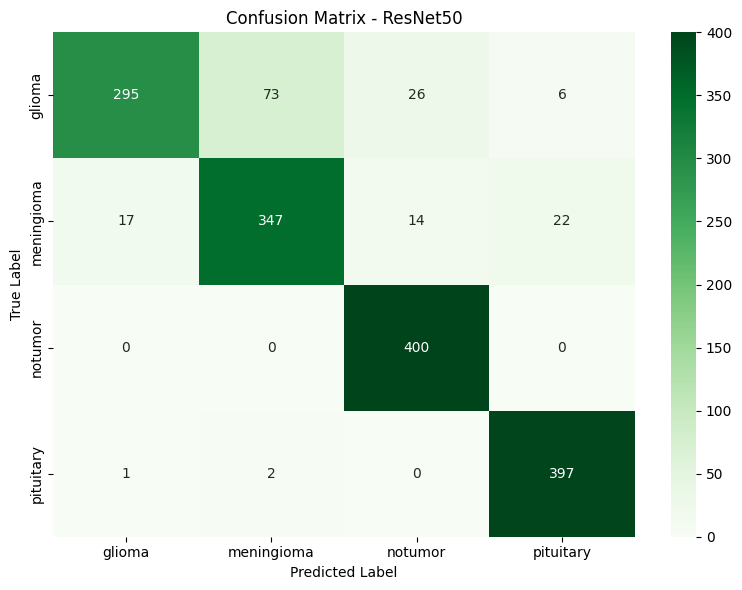

In [28]:
cm_resnet = confusion_matrix(y_true_resnet, y_pred_resnet)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_resnet, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - ResNet50")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "resnet50_confusion_matrix.png"), dpi=300, bbox_inches="tight")
plt.show()

#### Training, Testing & Evaluation - Xception 

In [40]:
# Load Xception base model at its native input size (299x299)
xception_base = tf.keras.applications.Xception(
    weights="imagenet",
    include_top=False,
    input_shape=(299, 299, 3)
)
xception_base.trainable = False

# Resizing layer brings 224x224 inputs up to Xception native 299x299
model_xception = models.Sequential([
    layers.Resizing(299, 299),
    tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
], name="augmentation_xception"),
    layers.Lambda(tf.keras.applications.xception.preprocess_input),
    xception_base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation="softmax")
])
model_xception.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing_2 (Resizing)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation_xception           │ ?                      │   0 (unbuilt) │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_5 (Lambda)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ xception (Functional)           │ (None, 10, 10, 2048)   │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,861,480 (79.58 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 20,861,480 (79.58 MB)

In [41]:
xception_start = time.time()

# Compile the model
model_xception.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_xception = model_xception.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=get_callbacks(),
    class_weight=class_weight_dict
)

# --- Fine-tuning: unfreeze last 15 layers of Xception ---
xception_base.trainable = True
for layer in xception_base.layers[:-15]:
    layer.trainable = False

model_xception.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_xception_ft = model_xception.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=get_callbacks(),
    class_weight=class_weight_dict
)

# Merge histories
for k in history_xception.history:
    history_xception.history[k].extend(history_xception_ft.history[k])

# Save the model after training
model_xception.save(os.path.join(OUTPUT_DIR, "xception_model.keras"))
print("Xception model saved.")

xception_time = time.time() - xception_start
print(f"Xception Total Training Time: {xception_time:.2f} seconds ({xception_time/60:.2f} minutes)")

Epoch 1/25

140/140 ━━━━━━━━━━━━━━━━━━━━ 671s 5s/step - accuracy: 0.6116 - loss: 1.0000 - val_accuracy: 0.8071 - val_loss: 0.6726 - learning_rate: 1.0000e-04
Epoch 2/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 649s 5s/step - accuracy: 0.7732 - loss: 0.6545 - val_accuracy: 0.8455 - val_loss: 0.5306 - learning_rate: 1.0000e-04
Epoch 3/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 658s 5s/step - accuracy: 0.8011 - loss: 0.5655 - val_accuracy: 0.8545 - val_loss: 0.4747 - learning_rate: 1.0000e-04
Epoch 4/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 656s 5s/step - accuracy: 0.8292 - loss: 0.5029 - val_accuracy: 0.8687 - val_loss: 0.4278 - learning_rate: 1.0000e-04
Epoch 5/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 661s 5s/step - accuracy: 0.8313 - loss: 0.4703 - val_accuracy: 0.8795 - val_loss: 0.3969 - learning_rate: 1.0000e-04
Epoch 6/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 660s 5s/step - accuracy: 0.8525 - loss: 0.4301 - val_accuracy: 0.8795 - val_loss: 0.3778 - learning_rate: 1.0000e-04
Epoch 7/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 656s 5s/step - ac

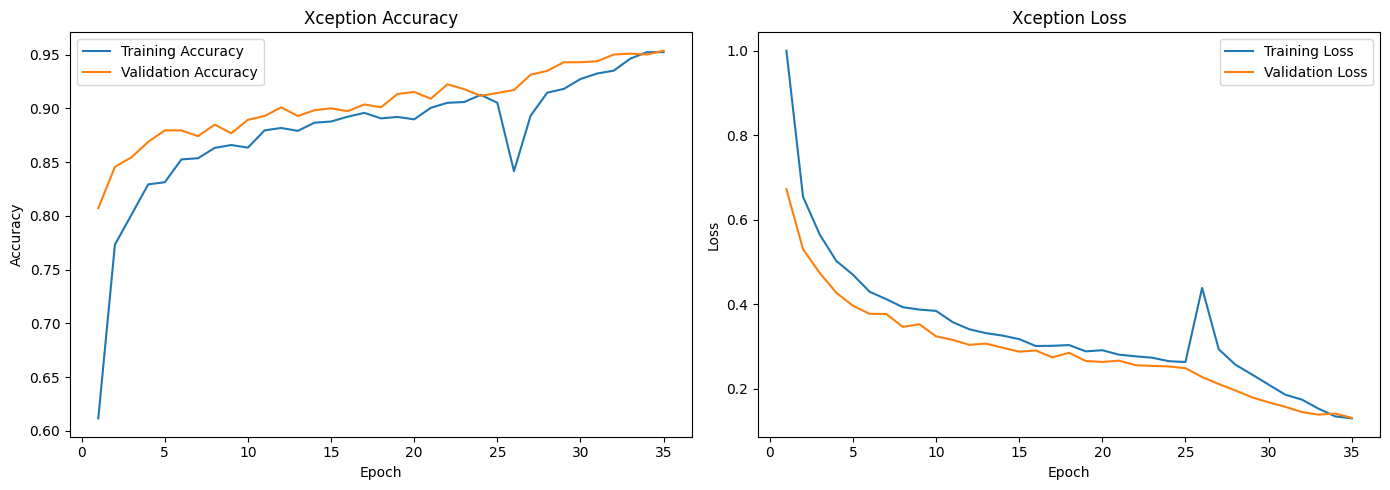

In [42]:
# Single training history
acc_xce = history_xception.history['accuracy']
val_acc_xce = history_xception.history['val_accuracy']

loss_xce = history_xception.history['loss']
val_loss_xce = history_xception.history['val_loss']

epochs_range_xce = range(1, len(acc_xce) + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range_xce, acc_xce, label='Training Accuracy')
plt.plot(epochs_range_xce, val_acc_xce, label='Validation Accuracy')
plt.title('Xception Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range_xce, loss_xce, label='Training Loss')
plt.plot(epochs_range_xce, val_loss_xce, label='Validation Loss')
plt.title('Xception Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "xception_accuracy_loss.png"), dpi=300, bbox_inches="tight")
plt.show()

In [43]:
test_loss_xception, test_acc_xception = model_xception.evaluate(test_ds)
print("Xception Test Accuracy:", test_acc_xception)
print("Xception Test Loss:", test_loss_xception)

y_true_xception = []
y_pred_xception = []

for images, labels in test_ds:
    predictions = model_xception.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true_xception.extend(labels.numpy())
    y_pred_xception.extend(predicted_labels)

y_true_xception = np.array(y_true_xception)
y_pred_xception = np.array(y_pred_xception)

report_xception = classification_report(y_true_xception, y_pred_xception, target_names=class_names)

print("Classification Report for Xception:\n")
print(report_xception)

with open(os.path.join(OUTPUT_DIR, "xception_classification_report.txt"), "w") as f:
    f.write(report_xception)

50/50 ━━━━━━━━━━━━━━━━━━━━ 245s 5s/step - accuracy: 0.9100 - loss: 0.3670
Xception Test Accuracy: 0.9100000262260437
Xception Test Loss: 0.3670239746570587
Classification Report for Xception:

              precision    recall  f1-score   support

      glioma       0.95      0.77      0.85       400
  meningioma       0.86      0.89      0.87       400
     notumor       0.89      1.00      0.94       400
   pituitary       0.94      0.99      0.96       400

    accuracy                           0.91      1600
   macro avg       0.91      0.91      0.91      1600
weighted avg       0.91      0.91      0.91      1600



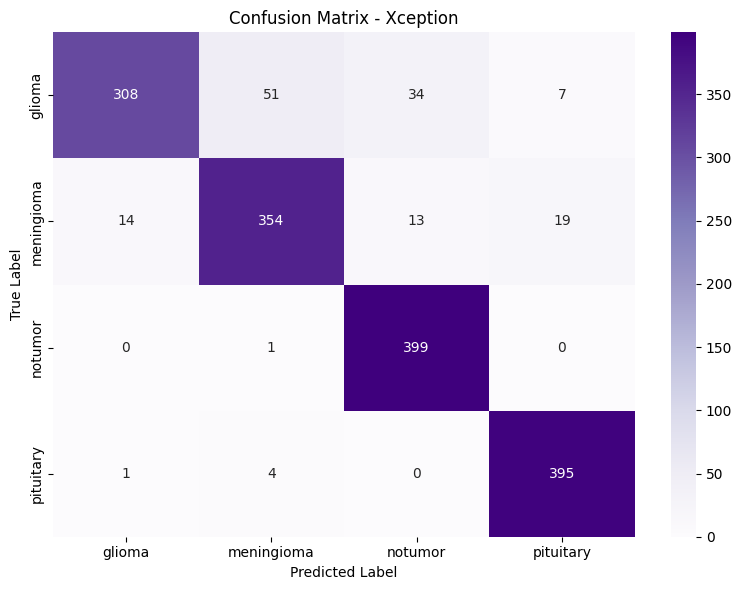

In [44]:
cm_xception = confusion_matrix(y_true_xception, y_pred_xception)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_xception, annot=True, fmt='d', cmap='Purples',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Xception")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "xception_confusion_matrix.png"), dpi=300, bbox_inches="tight")
plt.show()

 #### Training, Testing & Evaluation - EfficientNetB2

In [45]:
# Load EfficientNetB2 base model at its native input size (260x260)
efficientnet_base = tf.keras.applications.EfficientNetB2(
    weights="imagenet",
    include_top=False,
    input_shape=(260, 260, 3)
)
efficientnet_base.trainable = False

# Resizing layer brings 224x224 inputs up to EfficientNetB2 native 260x260
model_efficientnet = models.Sequential([
    layers.Resizing(260, 260),
    tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
], name="augmentation_efficientnet"),
    efficientnet_base,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation="softmax")
])
model_efficientnet.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing_3 (Resizing)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation_efficientnet       │ ?                      │   0 (unbuilt) │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb2 (Functional)     │ (None, 9, 9, 1408)     │     7,768,569 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_6      │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,768,569 (29.63 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 7,768,569 (29.63 MB)

In [46]:
efficientnet_start = time.time()

# Compile the model
model_efficientnet.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_efficientnet = model_efficientnet.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=get_callbacks(),
    class_weight=class_weight_dict
)

# --- Fine-tuning: unfreeze last 20 layers of EfficientNetB2 ---
efficientnet_base.trainable = True
for layer in efficientnet_base.layers[:-20]:
    layer.trainable = False

model_efficientnet.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_efficientnet_ft = model_efficientnet.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=get_callbacks(),
    class_weight=class_weight_dict
)

# Merge histories
for k in history_efficientnet.history:
    history_efficientnet.history[k].extend(history_efficientnet_ft.history[k])

# Save the model after training
model_efficientnet.save(os.path.join(OUTPUT_DIR, "efficientnetb2_model.keras"))
print("EfficientNetB2 model saved.")

efficientnet_time = time.time() - efficientnet_start
print(f"EfficientNetB2 Total Training Time: {efficientnet_time:.2f} seconds ({efficientnet_time/60:.2f} minutes)")

Epoch 1/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 353s 2s/step - accuracy: 0.5810 - loss: 1.1408 - val_accuracy: 0.8045 - val_loss: 0.6969 - learning_rate: 1.0000e-04
Epoch 2/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 293s 2s/step - accuracy: 0.7308 - loss: 0.7270 - val_accuracy: 0.8339 - val_loss: 0.4624 - learning_rate: 1.0000e-04
Epoch 3/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 287s 2s/step - accuracy: 0.7688 - loss: 0.6201 - val_accuracy: 0.8545 - val_loss: 0.3774 - learning_rate: 1.0000e-04
Epoch 4/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 299s 2s/step - accuracy: 0.8103 - loss: 0.5125 - val_accuracy: 0.8741 - val_loss: 0.3400 - learning_rate: 1.0000e-04
Epoch 5/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 316s 2s/step - accuracy: 0.8150 - loss: 0.4920 - val_accuracy: 0.8848 - val_loss: 0.3085 - learning_rate: 1.0000e-04
Epoch 6/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 306s 2s/step - accuracy: 0.8259 - loss: 0.4607 - val_accuracy: 0.8857 - val_loss: 0.2978 - learning_rate: 1.0000e-04
Epoch 7/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 305s 2s/step - acc

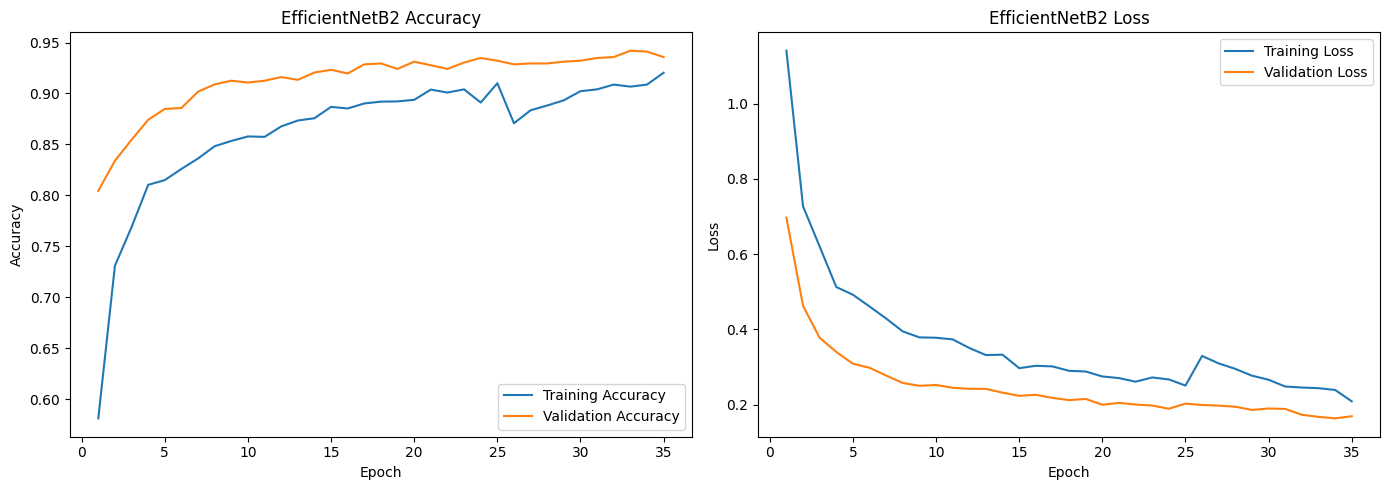

In [47]:
acc_eff = history_efficientnet.history['accuracy']
val_acc_eff = history_efficientnet.history['val_accuracy']

loss_eff = history_efficientnet.history['loss']
val_loss_eff = history_efficientnet.history['val_loss']

epochs_range_eff = range(1, len(acc_eff) + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range_eff, acc_eff, label='Training Accuracy')
plt.plot(epochs_range_eff, val_acc_eff, label='Validation Accuracy')
plt.title('EfficientNetB2 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range_eff, loss_eff, label='Training Loss')
plt.plot(epochs_range_eff, val_loss_eff, label='Validation Loss')
plt.title('EfficientNetB2 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "efficientnetb2_accuracy_loss.png"), dpi=300, bbox_inches="tight")
plt.show()

In [48]:
test_loss_efficientnet, test_acc_efficientnet = model_efficientnet.evaluate(test_ds)
print("EfficientNetB2 Test Accuracy:", test_acc_efficientnet)
print("EfficientNetB2 Test Loss:", test_loss_efficientnet)

y_true_efficientnet = []
y_pred_efficientnet = []

for images, labels in test_ds:
    predictions = model_efficientnet.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true_efficientnet.extend(labels.numpy())
    y_pred_efficientnet.extend(predicted_labels)

y_true_efficientnet = np.array(y_true_efficientnet)
y_pred_efficientnet = np.array(y_pred_efficientnet)

report_efficientnet = classification_report(y_true_efficientnet, y_pred_efficientnet, target_names=class_names)

print("Classification Report for EfficientNetB2:\n")
print(report_efficientnet)

with open(os.path.join(OUTPUT_DIR, "efficientnetb2_classification_report.txt"), "w") as f:
    f.write(report_efficientnet)

50/50 ━━━━━━━━━━━━━━━━━━━━ 86s 2s/step - accuracy: 0.8925 - loss: 0.3835
EfficientNetB2 Test Accuracy: 0.8924999833106995
EfficientNetB2 Test Loss: 0.38347241282463074
Classification Report for EfficientNetB2:

              precision    recall  f1-score   support

      glioma       0.93      0.76      0.83       400
  meningioma       0.84      0.84      0.84       400
     notumor       0.90      0.98      0.94       400
   pituitary       0.90      0.99      0.94       400

    accuracy                           0.89      1600
   macro avg       0.89      0.89      0.89      1600
weighted avg       0.89      0.89      0.89      1600



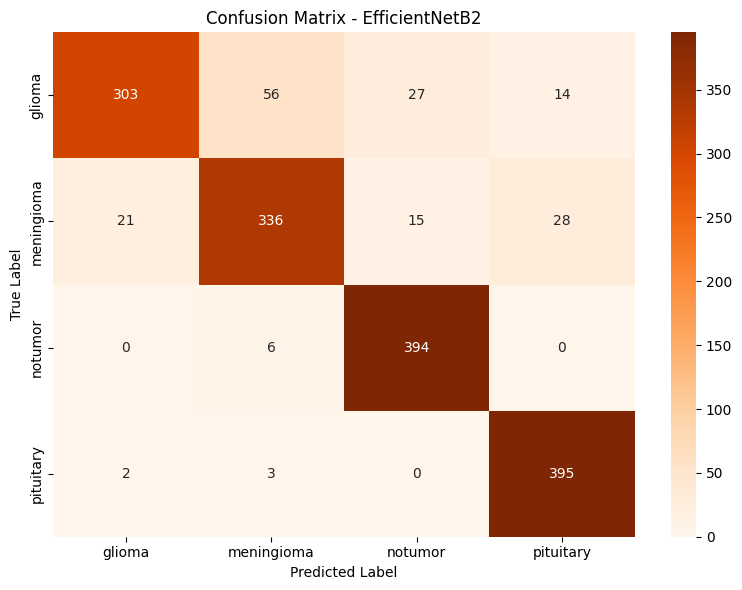

In [49]:
cm_efficientnet = confusion_matrix(y_true_efficientnet, y_pred_efficientnet)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_efficientnet, annot=True, fmt='d', cmap='Oranges',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - EfficientNetB2")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "efficientnetb2_confusion_matrix.png"), dpi=300, bbox_inches="tight")
plt.show()

In [50]:
# Parse all metrics from saved classification reports
def parse_report(txt_path, model_name):
    with open(txt_path, "r") as f:
        content = f.read()
    rows = []

    # Per-class + macro/weighted avg rows: label  precision  recall  f1  support
    for m in re.finditer(
        r"^[ \t]*(\S+(?:[ \t]\S+)*)[ \t]+(\d\.\d+)[ \t]+(\d\.\d+)[ \t]+(\d\.\d+)[ \t]+(\d+)\s*$",
        content, re.MULTILINE
    ):
        label, prec, rec, f1, sup = m.groups()
        label = label.strip()
        if label == "f1-score":
            continue
        rows.append({
            "Model": model_name, "Class": label,
            "Precision": float(prec), "Recall": float(rec),
            "F1-Score": float(f1), "Support": int(sup)
        })

    # Accuracy row (used only for downstream variables, not displayed in table)
    m_acc = re.search(
        r"^[ \t]*accuracy[ \t]+(\d\.\d+)[ \t]+(\d+)\s*$", content, re.MULTILINE
    )
    if m_acc:
        rows.append({
            "Model": model_name, "Class": "accuracy",
            "Precision": None, "Recall": None,
            "F1-Score": float(m_acc.group(1)), "Support": int(m_acc.group(2))
        })
    return rows

report_files = {
    "VGG16":          "vgg16_classification_report.txt",
    "ResNet50":       "resnet50_classification_report.txt",
    "Xception":       "xception_classification_report.txt",
    "EfficientNetB2": "efficientnetb2_classification_report.txt",
}

all_rows = []
for model_name, fname in report_files.items():
    all_rows.extend(parse_report(os.path.join(OUTPUT_DIR, fname), model_name))

metrics_df = pd.DataFrame(all_rows)

# Pull out overall accuracy per model for downstream cells
acc_row = metrics_df[metrics_df["Class"] == "accuracy"].set_index("Model")["F1-Score"]
test_acc_vgg          = acc_row["VGG16"]
test_acc_resnet       = acc_row["ResNet50"]
test_acc_xception     = acc_row["Xception"]
test_acc_efficientnet = acc_row["EfficientNetB2"]
test_loss_vgg = test_loss_resnet = test_loss_xception = test_loss_efficientnet = float("nan")

# Display pivot table (accuracy row excluded)
CLASS_ORDER = ["glioma", "meningioma", "notumor", "pituitary", "macro avg", "weighted avg"]
pivot = metrics_df.pivot_table(
    index="Class", columns="Model",
    values=["Precision", "Recall", "F1-Score"],
    aggfunc="first"
).round(3)
pivot = pivot.reindex([c for c in CLASS_ORDER if c in pivot.index])
print(pivot.to_string())


                   F1-Score                              Precision                                 Recall                        
Model        EfficientNetB2 ResNet50 VGG16 Xception EfficientNetB2 ResNet50 VGG16 Xception EfficientNetB2 ResNet50 VGG16 Xception
Class                                                                                                                            
glioma                 0.83     0.83  0.88     0.85           0.93     0.94  0.98     0.95           0.76     0.74  0.80     0.77
meningioma             0.84     0.84  0.91     0.87           0.84     0.82  0.87     0.86           0.84     0.87  0.94     0.89
notumor                0.94     0.95  0.96     0.94           0.90     0.91  0.93     0.89           0.98     1.00  1.00     1.00
pituitary              0.94     0.96  0.98     0.96           0.90     0.93  0.96     0.94           0.99     0.99  0.99     0.99
macro avg              0.89     0.90  0.93     0.91           0.89     0.90  0.94     0.91

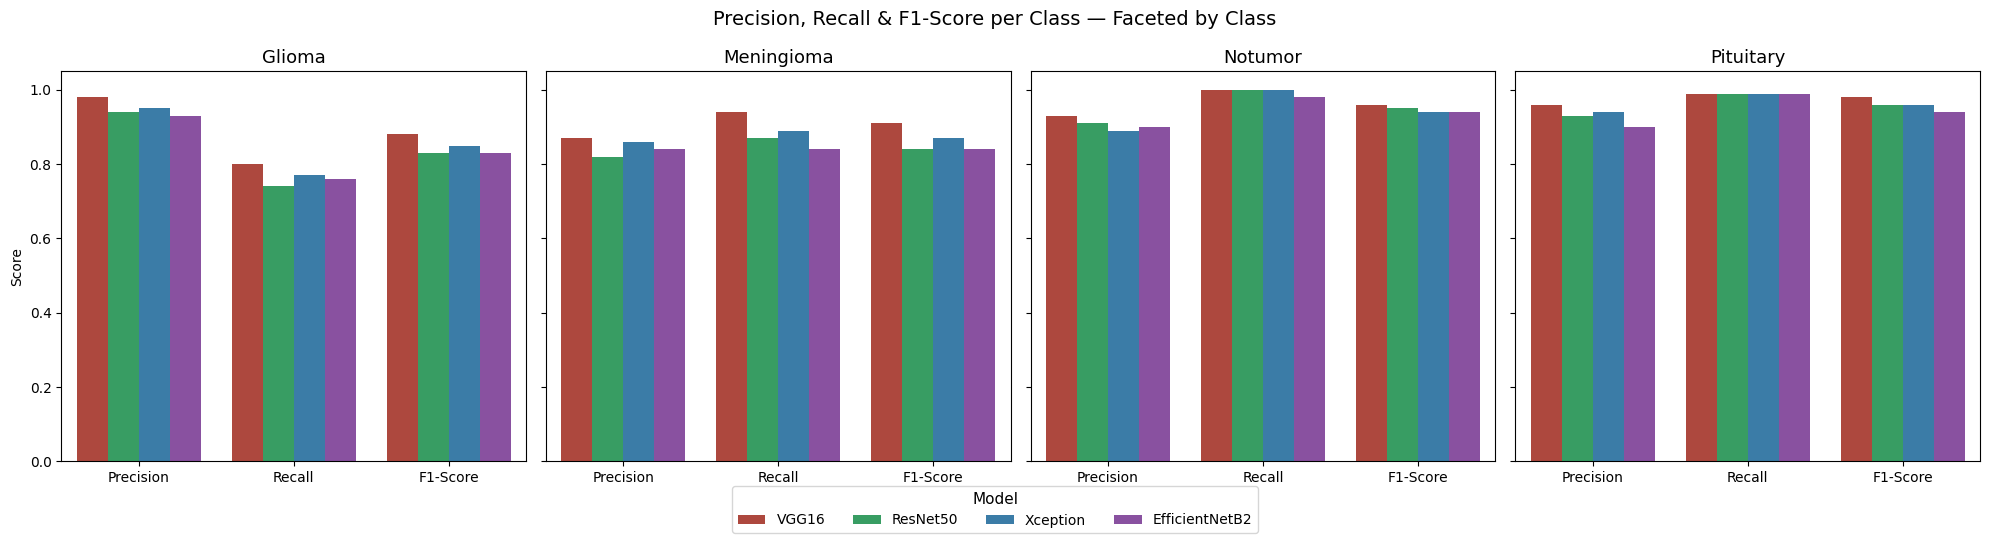

In [51]:
# Facet by class — each subplot shows P/R/F1 per model for one class
CLASSES = ["glioma", "meningioma", "notumor", "pituitary"]
METRICS = ["Precision", "Recall", "F1-Score"]
palette = ["#c0392b", "#27ae60", "#2980b9", "#8e44ad"]

plot_df = metrics_df[metrics_df["Class"].isin(CLASSES)].copy()
melted = plot_df.melt(id_vars=["Model", "Class"], value_vars=METRICS,
                      var_name="Metric", value_name="Score")

fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)

for ax, cls in zip(axes, CLASSES):
    subset = melted[melted["Class"] == cls]
    sns.barplot(data=subset, x="Metric", y="Score", hue="Model",
                palette=palette, ax=ax, order=METRICS)
    ax.set_title(cls.capitalize(), fontsize=13)
    ax.set_xlabel("")
    ax.set_ylabel("Score" if ax == axes[0] else "")
    ax.set_ylim(0, 1.05)
    ax.get_legend().remove()

# Single shared legend outside the figure
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Model", loc="lower center",
           ncol=4, fontsize=10, title_fontsize=11,
           bbox_to_anchor=(0.5, -0.08))

fig.suptitle("Precision, Recall & F1-Score per Class — Faceted by Class", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "metrics_facet_by_class.png"), dpi=300, bbox_inches="tight")
plt.show()


In [52]:
# Overall metrics table (Accuracy, Precision, Recall, F1-Score — macro avg)
macro = metrics_df[metrics_df["Class"] == "macro avg"].set_index("Model")

summary_df = pd.DataFrame({
    "Model":     ["VGG16", "ResNet50", "Xception", "EfficientNetB2"],
    "Accuracy":  [test_acc_vgg, test_acc_resnet, test_acc_xception, test_acc_efficientnet],
    "Precision": [macro.loc["VGG16", "Precision"], macro.loc["ResNet50", "Precision"],
                  macro.loc["Xception", "Precision"], macro.loc["EfficientNetB2", "Precision"]],
    "Recall":    [macro.loc["VGG16", "Recall"], macro.loc["ResNet50", "Recall"],
                  macro.loc["Xception", "Recall"], macro.loc["EfficientNetB2", "Recall"]],
    "F1-Score":  [macro.loc["VGG16", "F1-Score"], macro.loc["ResNet50", "F1-Score"],
                  macro.loc["Xception", "F1-Score"], macro.loc["EfficientNetB2", "F1-Score"]],
}).sort_values("Accuracy", ascending=False).reset_index(drop=True)

summary_df.index += 1
for col in ["Accuracy", "Precision", "Recall", "F1-Score"]:
    summary_df[col] = summary_df[col].map("{:.2f}".format)

print(summary_df.to_string())


            Model Accuracy Precision Recall F1-Score
1           VGG16     0.93      0.94   0.93     0.93
2        Xception     0.91      0.91   0.91     0.91
3        ResNet50     0.90      0.90   0.90     0.90
4  EfficientNetB2     0.89      0.89   0.89     0.89


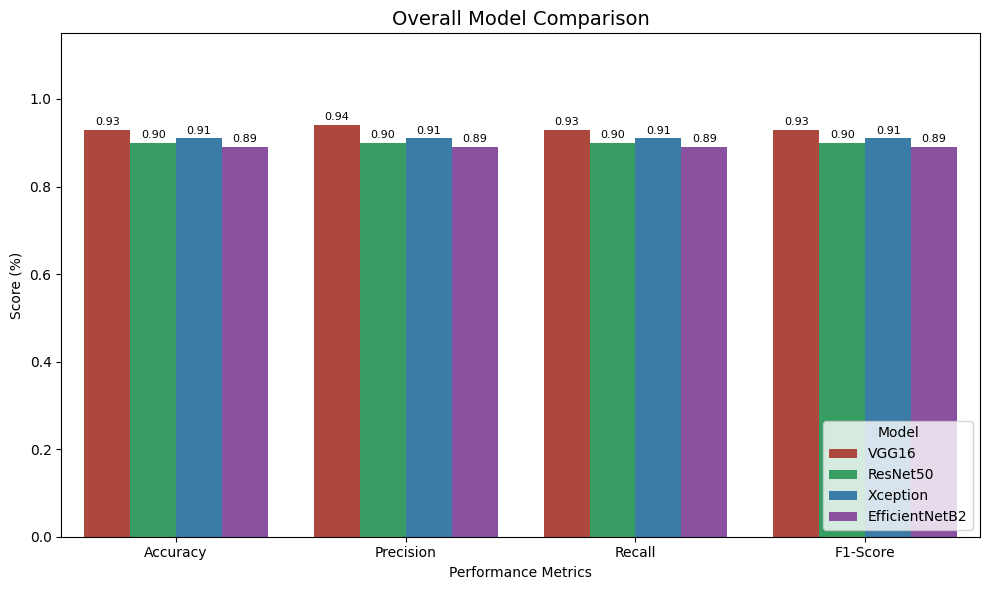

In [53]:
# Overall metrics grouped bar chart — metrics on x-axis, models as hue
macro = metrics_df[metrics_df["Class"] == "macro avg"].set_index("Model")

plot_df = pd.DataFrame({
    "Model":     ["VGG16", "ResNet50", "Xception", "EfficientNetB2"],
    "Accuracy":  [test_acc_vgg, test_acc_resnet, test_acc_xception, test_acc_efficientnet],
    "Precision": [macro.loc["VGG16", "Precision"], macro.loc["ResNet50", "Precision"],
                  macro.loc["Xception", "Precision"], macro.loc["EfficientNetB2", "Precision"]],
    "Recall":    [macro.loc["VGG16", "Recall"], macro.loc["ResNet50", "Recall"],
                  macro.loc["Xception", "Recall"], macro.loc["EfficientNetB2", "Recall"]],
    "F1-Score":  [macro.loc["VGG16", "F1-Score"], macro.loc["ResNet50", "F1-Score"],
                  macro.loc["Xception", "F1-Score"], macro.loc["EfficientNetB2", "F1-Score"]],
})

melted = plot_df.melt(id_vars="Model", var_name="Metric", value_name="Score")
palette = ["#c0392b", "#27ae60", "#2980b9", "#8e44ad"]
METRIC_ORDER = ["Accuracy", "Precision", "Recall", "F1-Score"]

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=melted, x="Metric", y="Score", hue="Model",
                 palette=palette, order=METRIC_ORDER)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", fontsize=8, padding=2)

plt.title("Overall Model Comparison", fontsize=14)
plt.xlabel("Performance Metrics")
plt.ylabel("Score (%)" )
plt.ylim(0, 1.15)
plt.legend(title="Model", loc="lower right")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "overall_metrics_comparison.png"), dpi=300, bbox_inches="tight")
plt.show()


#### Compute Inference Time Using All Models

In [19]:
# Realistic inference: load 25 images per class (100 total, balanced across all 4 classes)
ARCHIVE_DIR = os.path.join(os.getcwd(), "archive")
TEST_DIR    = os.path.join(ARCHIVE_DIR, "Testing")

SAMPLES_PER_CLASS = 25
class_folders = sorted(os.listdir(TEST_DIR))  # sorted: glioma, meningioma, notumor, pituitary

real_images = []
for cls in class_folders:
    cls_dir = os.path.join(TEST_DIR, cls)
    img_files = sorted(os.listdir(cls_dir))[:SAMPLES_PER_CLASS]
    for fname in img_files:
        img_path = os.path.join(cls_dir, fname)
        img = tf.keras.utils.load_img(img_path, target_size=(224, 224))
        img = tf.keras.utils.img_to_array(img)          # shape: (224, 224, 3)
        img = np.expand_dims(img, axis=0).astype(np.float32)  # shape: (1, 224, 224, 3)
        real_images.append(img)

print(f"Classes found: {class_folders}")
print(f"Total images loaded: {len(real_images)} ({SAMPLES_PER_CLASS} per class)")


Classes found: ['glioma', 'meningioma', 'notumor', 'pituitary']
Total images loaded: 100 (25 per class)


VGG16: 27.222s total | 272.216 ms/image
ResNet50: 14.329s total | 143.290 ms/image
Xception: 17.921s total | 179.213 ms/image
EfficientNetB2: 11.054s total | 110.545 ms/image

         Model  Total Time (s)  Avg Time per Image (ms)  Samples
         VGG16          27.222                  272.216    100.0
      Xception          17.921                  179.213    100.0
      ResNet50          14.329                  143.290    100.0
EfficientNetB2          11.054                  110.545    100.0


C:\Users\HP\AppData\Local\Temp\ipykernel_4948\2605527691.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="Model", y=col, data=realistic_df, palette=palette)


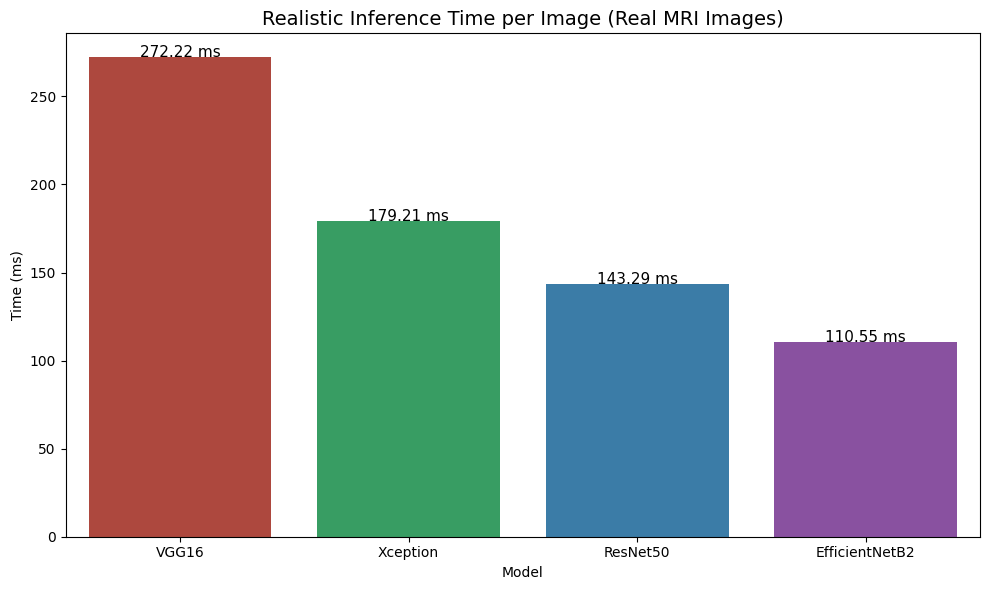

In [20]:
# Measure realistic inference time on real MRI images
NUM_REAL_SAMPLES = len(real_images)

realistic_results = {}

for model_name, (model, _) in models_dict.items():
    # Warm-up run
    _ = model.predict(real_images[0], verbose=0)

    # Timed runs on varied real images
    start = time.time()
    for img in real_images:
        model.predict(img, verbose=0)
    elapsed = time.time() - start

    ms_per_image = (elapsed / NUM_REAL_SAMPLES) * 1000
    realistic_results[model_name] = {
        "Total Time (s)": round(elapsed, 3),
        "Avg Time per Image (ms)": round(ms_per_image, 3),
        "Samples": NUM_REAL_SAMPLES
    }
    print(f"{model_name}: {elapsed:.3f}s total | {ms_per_image:.3f} ms/image")

realistic_df = pd.DataFrame(realistic_results).T.reset_index().rename(columns={"index": "Model"})
realistic_df = realistic_df.sort_values("Avg Time per Image (ms)", ascending=False).reset_index(drop=True)
print()
print(realistic_df.to_string(index=False))

# Bar chart
col = "Avg Time per Image (ms)"
plt.figure(figsize=(10, 6))
palette = ["#c0392b", "#27ae60", "#2980b9", "#8e44ad"]
ax = sns.barplot(x="Model", y=col, data=realistic_df, palette=palette)
plt.title("Realistic Inference Time per Image (Real MRI Images)", fontsize=14)
plt.ylabel("Time (ms)")
plt.xlabel("Model")
for index, row in realistic_df.iterrows():
    ax.text(index, row[col] + 0.05, f"{row[col]:.2f} ms", ha="center", fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "realistic_inference_time_comparison.png"), dpi=300, bbox_inches="tight")
plt.show()
